**0. 라이브러리 불러오기**

In [1]:
# PyTorch 핵심 라이브러리
import torch

# 신경망 모델을 만들기 위한 모듈
import torch.nn as nn

# 최적화 알고리즘을 사용하기 위한 모듈
import torch.optim as optim

# 데이터셋 분리, 평가 지표 사용
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report

# 데이터 전처리용
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 실습용 데이터셋
import seaborn as sns

# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt

# 실행 장치 설정
# GPU가 있으면 cuda, 없으면 cpu 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

사용 장치: cuda


# 1. PyTorch 회귀 모델 실습
   데이터셋: tips <br>
   목표: total_bill 값을 이용하여 tip 예측


In [2]:
# seaborn에서 tips 데이터셋 불러오기
tips = sns.load_dataset("tips")

# 데이터 앞부분 확인
print(tips.head())

# 데이터 기본 정보 확인
print(tips.info())

# 수치형 데이터 통계 확인
print(tips.describe())

# 독립변수 X 설정
# total_bill: 전체 식사 금액
X = tips[["total_bill"]].values

# 종속변수 y 설정
# tip: 팁 금액
y = tips[["tip"]].values

# 학습 데이터와 테스트 데이터 분리
# test_size=0.2는 전체 데이터의 20%를 테스트용으로 사용한다는 의미
# random_state는 항상 같은 결과가 나오도록 고정하는 값
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 입력 데이터 스케일링
# PyTorch 모델은 값의 크기가 너무 크거나 차이가 심하면 학습이 불안정할 수 있으므로 표준화한다.
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# 출력값 y도 스케일링
# 회귀 문제에서 y 값도 표준화하면 학습이 더 안정적이다.
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# NumPy 배열을 PyTorch Tensor로 변환
# dtype=torch.float32는 딥러닝 연산에 많이 사용하는 실수형 자료형이다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

# 데이터 크기 확인
print("X_train:", X_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test:", y_test_tensor.shape)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672


# 2. 회귀 모델 클래스 정의

In [3]:
class RegressionModel(nn.Module):
    # nn.Module은 PyTorch에서 모든 신경망 모델의 기본 부모 클래스이다.
    def __init__(self):
        # 부모 클래스 nn.Module의 초기화 기능 실행
        super().__init__()

        # 입력 1개(total_bill)를 받아 출력 1개(tip)를 예측하는 선형 계층
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        # 입력 x가 선형 계층을 통과하여 예측값을 만든다.
        return self.linear(x)


# 회귀 모델 객체 생성 후 GPU 또는 CPU로 이동
reg_model = RegressionModel().to(device)

# 손실 함수 설정
# MSELoss는 평균제곱오차로, 회귀 문제에서 많이 사용한다.
criterion = nn.MSELoss()

# 최적화 알고리즘 설정
# Adam은 학습률을 자동 조절하는 대표적인 최적화 알고리즘이다.
optimizer = optim.Adam(reg_model.parameters(), lr=0.01)

print(reg_model)

RegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


# 3. 회귀 모델 학습

In [4]:
# 전체 학습 반복 횟수
epochs = 1000

# 학습 손실값을 저장할 리스트
loss_history = []

for epoch in range(epochs):
    # 모델을 학습 모드로 설정
    reg_model.train()

    # 이전 반복에서 계산된 기울기 초기화
    optimizer.zero_grad()

    # 모델 예측값 계산
    y_pred = reg_model(X_train_tensor)

    # 예측값과 실제값 사이의 손실 계산
    loss = criterion(y_pred, y_train_tensor)

    # 역전파 수행
    # 각 가중치가 손실에 얼마나 영향을 주었는지 기울기 계산
    loss.backward()

    # 계산된 기울기를 바탕으로 가중치 업데이트
    optimizer.step()

    # 손실값 저장
    loss_history.append(loss.item())

    # 100번마다 학습 상태 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [100/1000], Loss: 0.569307
Epoch [200/1000], Loss: 0.569049
Epoch [300/1000], Loss: 0.569049
Epoch [400/1000], Loss: 0.569049
Epoch [500/1000], Loss: 0.569049
Epoch [600/1000], Loss: 0.569049
Epoch [700/1000], Loss: 0.569049
Epoch [800/1000], Loss: 0.569049
Epoch [900/1000], Loss: 0.569049
Epoch [1000/1000], Loss: 0.569049


# 4. 회귀 모델 평가

In [5]:
# 평가 모드로 변경
reg_model.eval()

# 평가 시에는 기울기 계산이 필요 없으므로 no_grad 사용
with torch.no_grad():
    # 테스트 데이터 예측
    y_pred_scaled = reg_model(X_test_tensor)

# Tensor를 NumPy 배열로 변환
y_pred_scaled_np = y_pred_scaled.cpu().numpy()

# 스케일링된 예측값을 원래 tip 단위로 복원
y_pred_original = y_scaler.inverse_transform(y_pred_scaled_np)

# 실제 y_test도 원래 단위로 사용
y_test_original = y_test

# 평균제곱오차 계산
mse = mean_squared_error(y_test_original, y_pred_original)

# 결정계수 계산
r2 = r2_score(y_test_original, y_pred_original)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 0.5688142500106801
R^2 Score: 0.5449381682533387


# 5. 회귀 결과 시각화

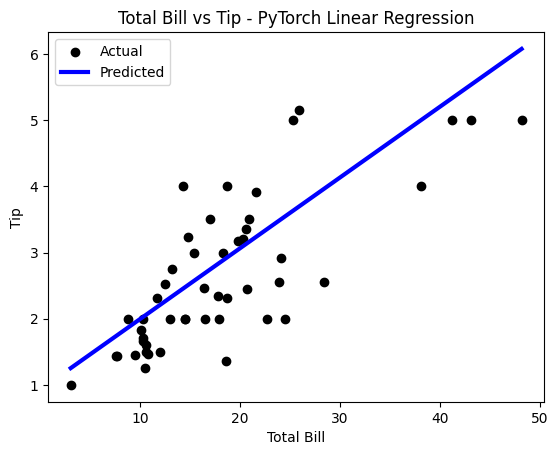

In [6]:
# 산점도: 실제 데이터
plt.scatter(X_test, y_test_original, color="black", label="Actual")

# 선 그래프를 보기 좋게 정렬하기 위해 X값 기준으로 정렬
sorted_index = np.argsort(X_test.flatten())

# 정렬된 X_test
X_test_sorted = X_test[sorted_index]

# 정렬된 예측값
y_pred_sorted = y_pred_original[sorted_index]

# 예측 회귀선 출력
plt.plot(X_test_sorted, y_pred_sorted, color="blue", linewidth=3, label="Predicted")

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip - PyTorch Linear Regression")
plt.legend()
plt.show()

# 6. 회귀 모델 학습 손실 시각화

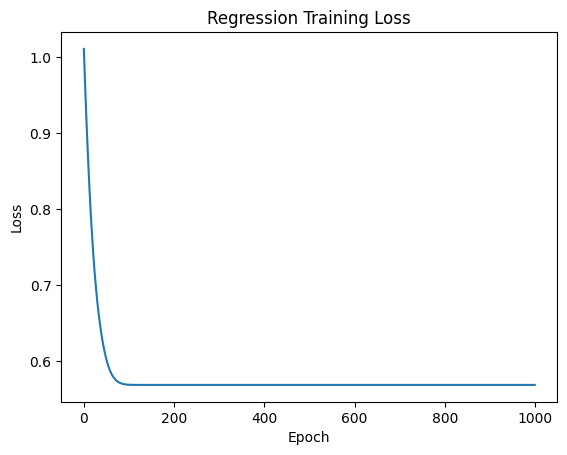

In [7]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regression Training Loss")
plt.show()

# 7. PyTorch 분류 모델 실습
#    데이터셋: iris
#    목표: 꽃받침/꽃잎 정보를 이용하여 붓꽃 품종 분류

In [8]:
# iris 데이터셋 불러오기
data = sns.load_dataset("iris")

# 데이터 앞부분 확인
print(data.head())

# 데이터 정보 확인
print(data.info())

# 통계 정보 확인
print(data.describe())

# 독립변수 설정
# species 컬럼을 제외한 나머지 4개 수치형 컬럼 사용
X = data.drop("species", axis=1).values

# 종속변수 설정
# 품종 이름 문자열
y = data["species"].values

# 문자열 라벨을 숫자 라벨로 변환
# setosa -> 0, versicolor -> 1, virginica -> 2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("라벨 클래스:", label_encoder.classes_)
print("변환된 라벨 예시:", y_encoded[:10])

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 입력 데이터 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PyTorch Tensor로 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# 분류 문제의 정답 라벨은 LongTensor를 사용한다.
# CrossEntropyLoss가 정수형 클래스 라벨을 요구하기 때문이다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

print("X_train:", X_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test:", y_test_tensor.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333  

# 8. 분류 모델 클래스 정의

In [9]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 입력 특성 4개
        # sepal_length, sepal_width, petal_length, petal_width
        self.fc1 = nn.Linear(4, 16)

        # 은닉층 16개 노드에서 다시 8개 노드로 변환
        self.fc2 = nn.Linear(16, 8)

        # 최종 출력층
        # iris 품종은 3개 클래스이므로 출력 노드는 3개
        self.fc3 = nn.Linear(8, 3)

        # 활성화 함수 ReLU
        self.relu = nn.ReLU()

    def forward(self, x):
        # 첫 번째 선형 계층 통과 후 ReLU 적용
        x = self.relu(self.fc1(x))

        # 두 번째 선형 계층 통과 후 ReLU 적용
        x = self.relu(self.fc2(x))

        # 출력층
        # CrossEntropyLoss는 내부에서 Softmax를 처리하므로 여기서는 Softmax를 적용하지 않는다.
        x = self.fc3(x)

        return x


# 분류 모델 생성
clf_model = ClassificationModel().to(device)

# 분류 손실 함수
# 다중 클래스 분류에서는 CrossEntropyLoss를 주로 사용한다.
criterion = nn.CrossEntropyLoss()

# 최적화 알고리즘
optimizer = optim.Adam(clf_model.parameters(), lr=0.01)

print(clf_model)

ClassificationModel(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)


# 9. 분류 모델 학습

In [10]:
epochs = 500

loss_history = []

for epoch in range(epochs):
    # 학습 모드 설정
    clf_model.train()

    # 이전 기울기 초기화
    optimizer.zero_grad()

    # 모델 출력값 계산
    # 출력 shape: [데이터개수, 클래스개수]
    outputs = clf_model(X_train_tensor)

    # 손실 계산
    loss = criterion(outputs, y_train_tensor)

    # 역전파로 기울기 계산
    loss.backward()

    # 가중치 업데이트
    optimizer.step()

    # 손실 저장
    loss_history.append(loss.item())

    # 50번마다 출력
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [50/500], Loss: 0.114662
Epoch [100/500], Loss: 0.034972
Epoch [150/500], Loss: 0.023391
Epoch [200/500], Loss: 0.010066
Epoch [250/500], Loss: 0.003427
Epoch [300/500], Loss: 0.001370
Epoch [350/500], Loss: 0.000760
Epoch [400/500], Loss: 0.000486
Epoch [450/500], Loss: 0.000351
Epoch [500/500], Loss: 0.000269


# 10. 분류 모델 평가

In [11]:
# 평가 모드 설정
clf_model.eval()

with torch.no_grad():
    # 테스트 데이터에 대한 출력값 계산
    outputs = clf_model(X_test_tensor)

    # 가장 큰 값을 가진 클래스 번호 선택
    _, predicted = torch.max(outputs, 1)

# Tensor를 NumPy 배열로 변환
y_pred = predicted.cpu().numpy()

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# 숫자 라벨을 다시 문자열 라벨로 복원
y_test_names = label_encoder.inverse_transform(y_test)
y_pred_names = label_encoder.inverse_transform(y_pred)

# 분류 리포트 출력
print(classification_report(y_test_names, y_pred_names))

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# 11. 분류 결과 시각화

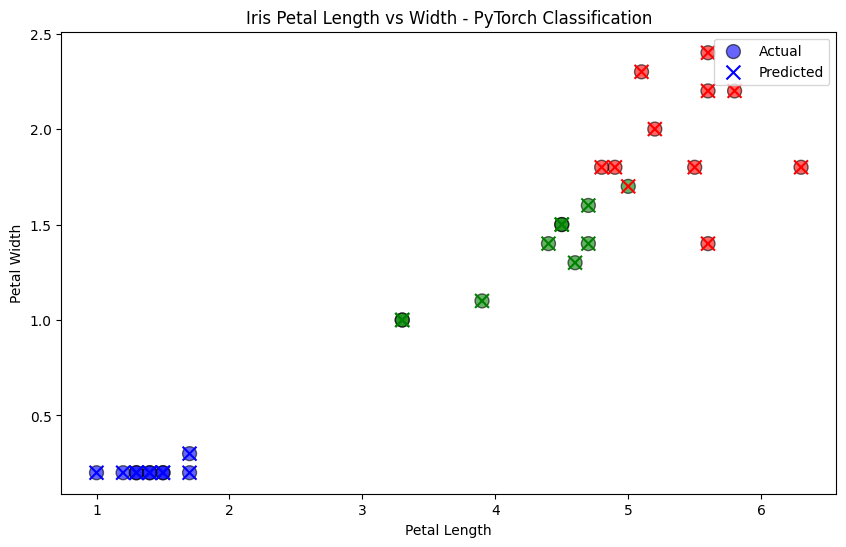

In [12]:
# X_test를 DataFrame으로 변환
# 시각화에서 petal_length, petal_width 컬럼명을 사용하기 위함
X_test_df = pd.DataFrame(
    X_test,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

# 실제 라벨과 예측 라벨을 문자열로 변환
y_test_series = pd.Series(y_test_names)
y_pred_series = pd.Series(y_pred_names)

# 클래스별 색상 매핑
color_mapping = {
    "setosa": "blue",
    "versicolor": "green",
    "virginica": "red"
}

plt.figure(figsize=(10, 6))

# 실제 라벨 시각화
plt.scatter(
    X_test_df["petal_length"],
    X_test_df["petal_width"],
    c=y_test_series.map(color_mapping),
    label="Actual",
    marker="o",
    edgecolor="k",
    s=100,
    alpha=0.6
)

# 예측 라벨 시각화
plt.scatter(
    X_test_df["petal_length"],
    X_test_df["petal_width"],
    c=y_pred_series.map(color_mapping),
    label="Predicted",
    marker="x",
    s=100,
    alpha=1.0
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Petal Length vs Width - PyTorch Classification")
plt.legend()
plt.show()

# 12. 분류 모델 학습 손실 시각화

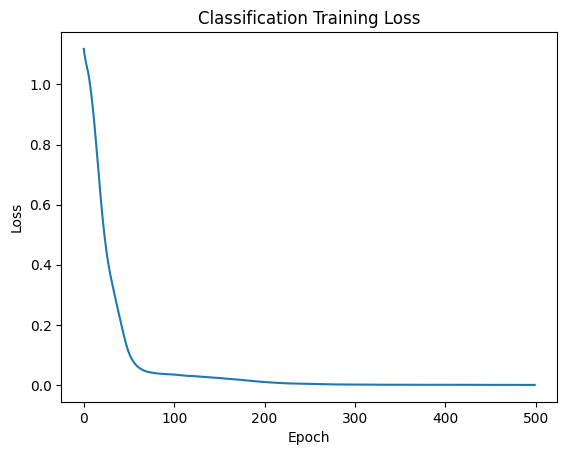

In [13]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Training Loss")
plt.show()

# 13. 새 데이터 예측 예제

In [14]:
# 예측할 새 붓꽃 데이터
# 순서: sepal_length, sepal_width, petal_length, petal_width
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])

# 학습 때 사용한 scaler로 동일하게 표준화
new_data_scaled = scaler.transform(new_data)

# Tensor로 변환
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32).to(device)

# 예측
clf_model.eval()

with torch.no_grad():
    output = clf_model(new_data_tensor)
    _, predicted_class = torch.max(output, 1)

# 숫자 라벨을 품종 이름으로 변환
predicted_name = label_encoder.inverse_transform(predicted_class.cpu().numpy())

print("예측 품종:", predicted_name[0])

예측 품종: setosa
